In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
print('OK')

OK


In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df_raw = pd.read_csv(
    filename,
    sep=';',
    encoding='latin-1',
    skiprows=4,
    na_values=['-']   # trata '-' como NaN
)

print(f'Shape: {df_raw.shape}')
df_raw.head()

Saving sinannet_cnv_denguebsp145121189_79_116_19.csv to sinannet_cnv_denguebsp145121189_79_116_19.csv
Shape: (672, 8)


,Município de notificação,2019,2020,2021,2022,2023,2024,Total
0,350010 ADAMANTINA,2080.0,1055.0,11.0,1331.0,3348.0,159.0,7984.0
1,350020 ADOLFO,105.0,7.0,89.0,161.0,17.0,148.0,527.0
2,350030 AGUAI,582.0,1977.0,22.0,8.0,8.0,515.0,3112.0
3,350040 AGUAS DA PRATA,25.0,26.0,1.0,NaN,10.0,235.0,297.0
4,350050 AGUAS DE LINDOIA,29.0,5.0,4.0,22.0,3.0,1383.0,1446.0


In [ ]:
ANOS = ['2019', '2020', '2021', '2022', '2023', '2024']
COL_MUNICIPIO = df_raw.columns[0]

df = df_raw[[COL_MUNICIPIO] + ANOS].copy()
df.columns = ['Municipio'] + ANOS

# Remove linha TOTAL
df = df[~df['Municipio'].str.upper().str.contains('TOTAL', na=False)]

# Trata valores ausentes
for col in ANOS:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Remove código do nome do município
df['Municipio'] = df['Municipio'].str.replace(r'^\d+\s*', '', regex=True).str.strip()

# Mantém apenas linhas com nome de município válido
df = df[df['Municipio'].str.match(r'^[A-Za-z]', na=False)]
df = df[df['Municipio'].str.len() <= 30]

# Remove linha de rodapé
df = df[~df['Municipio'].str.upper().str.startswith('NOTAS')]

print(f'Municípios: {len(df)}')
print(f'Nulos restantes: {df[ANOS].isnull().sum().sum()}')
df.head()

Municípios: 645
Nulos restantes: 0


,Municipio,2019,2020,2021,2022,2023,2024
0,ADAMANTINA,2080,1055,11,1331,3348,159
1,ADOLFO,105,7,89,161,17,148
2,AGUAI,582,1977,22,8,8,515
3,AGUAS DA PRATA,25,26,1,0,10,235
4,AGUAS DE LINDOIA,29,5,4,22,3,1383


In [ ]:
X_raw = df[ANOS].values.astype(float)

# Aplicação de log1p
X_log = np.log1p(X_raw)

# Z-score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

In [ ]:
#Coeficiente de SIlhueta
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_k = silhouette_score(X_scaled, labels)
    print(f'K={k:2d} - Silhueta: {sil_k:.4f}')

K= 2 - Silhueta: 0.2792
K= 3 - Silhueta: 0.2411
K= 4 - Silhueta: 0.2108
K= 5 - Silhueta: 0.2019
K= 6 - Silhueta: 0.2001
K= 7 - Silhueta: 0.1898
K= 8 - Silhueta: 0.1891
K= 9 - Silhueta: 0.1719
K=10 - Silhueta: 0.1770


In [ ]:
# K-means
K_FINAL = 3

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['Cluster'])
print(f'K={K_FINAL}, Silhueta: {sil:.4f}')
print()
print(df['Cluster'].value_counts().sort_index())

K=3, Silhueta: 0.2411

Cluster
0    155
1    163
2    327
Name: count, dtype: int64


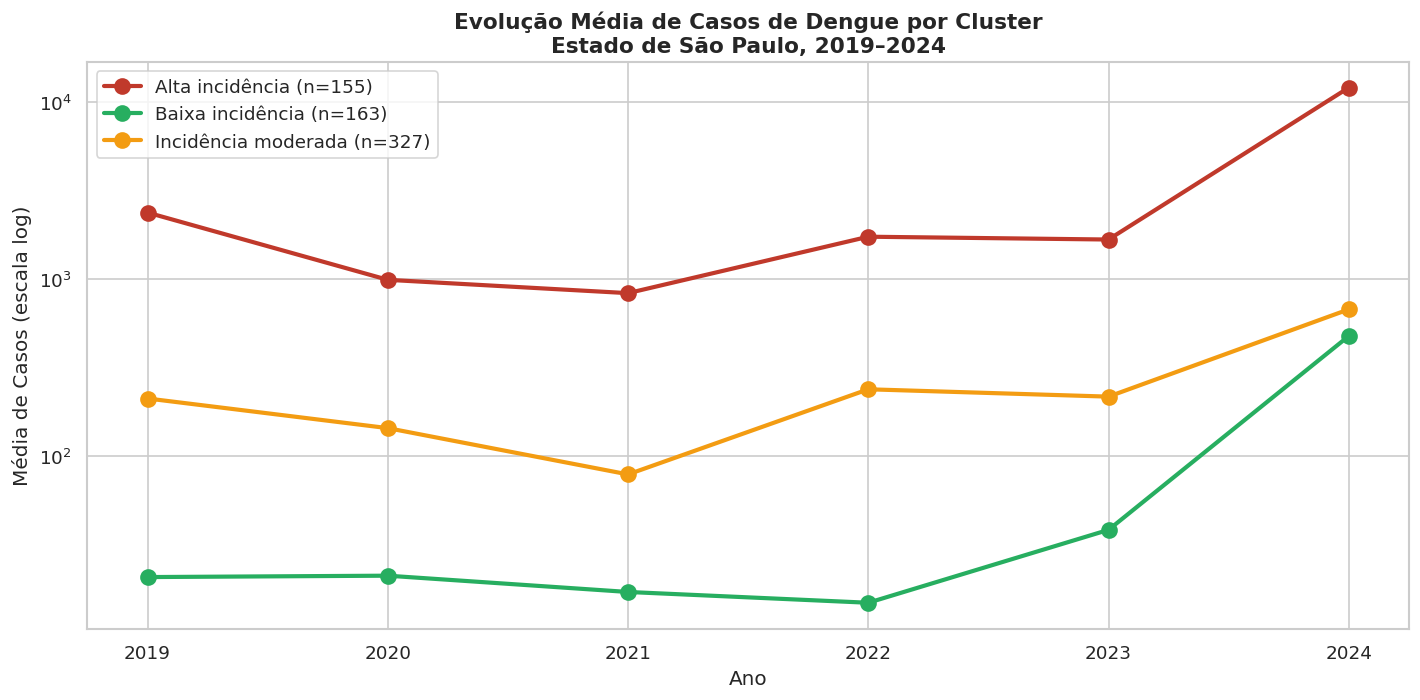

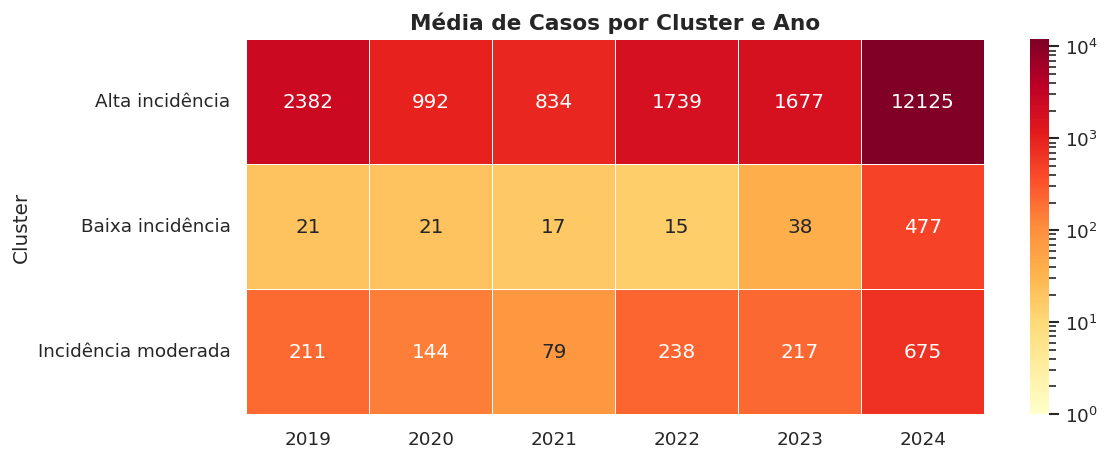

In [ ]:
# Perfil médio por cluster
perfil = df.groupby('Cluster')[ANOS].mean().round(0)

# Rótulos
rotulos = {
    0: 'Alta incidência',
    1: 'Baixa incidência',
    2: 'Incidência moderada'
}

cores_mapa = {0: '#C0392B', 1: '#27AE60', 2: '#F39C12'}
cores = [cores_mapa[c] for c in range(K_FINAL)]

# Gráfico 1: Evolução temporal
fig, ax = plt.subplots(figsize=(12, 6))
for i, c in enumerate(range(K_FINAL)):
    media = df[df['Cluster'] == c][ANOS].mean()
    n = (df['Cluster'] == c).sum()
    ax.plot(ANOS, media, 'o-', color=cores[i], linewidth=2.5,
            markersize=9, label=f'{rotulos[c]} (n={n})')
ax.set_yscale('log')
ax.set_title('Evolução Média de Casos de Dengue por Cluster\nEstado de São Paulo, 2019–2024',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Média de Casos (escala log)')
ax.legend()
plt.tight_layout()
plt.savefig('clusters_evolucao.png', bbox_inches='tight')
plt.show()

# Gráfico 2: Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    perfil[ANOS],
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    norm=mcolors.LogNorm(vmin=1, vmax=perfil[ANOS].values.max()),
    linewidths=0.5, ax=ax,
    yticklabels=[rotulos[i] for i in perfil.index]
)
ax.set_title('Média de Casos por Cluster e Ano', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_clusters.png', bbox_inches='tight')
plt.show()

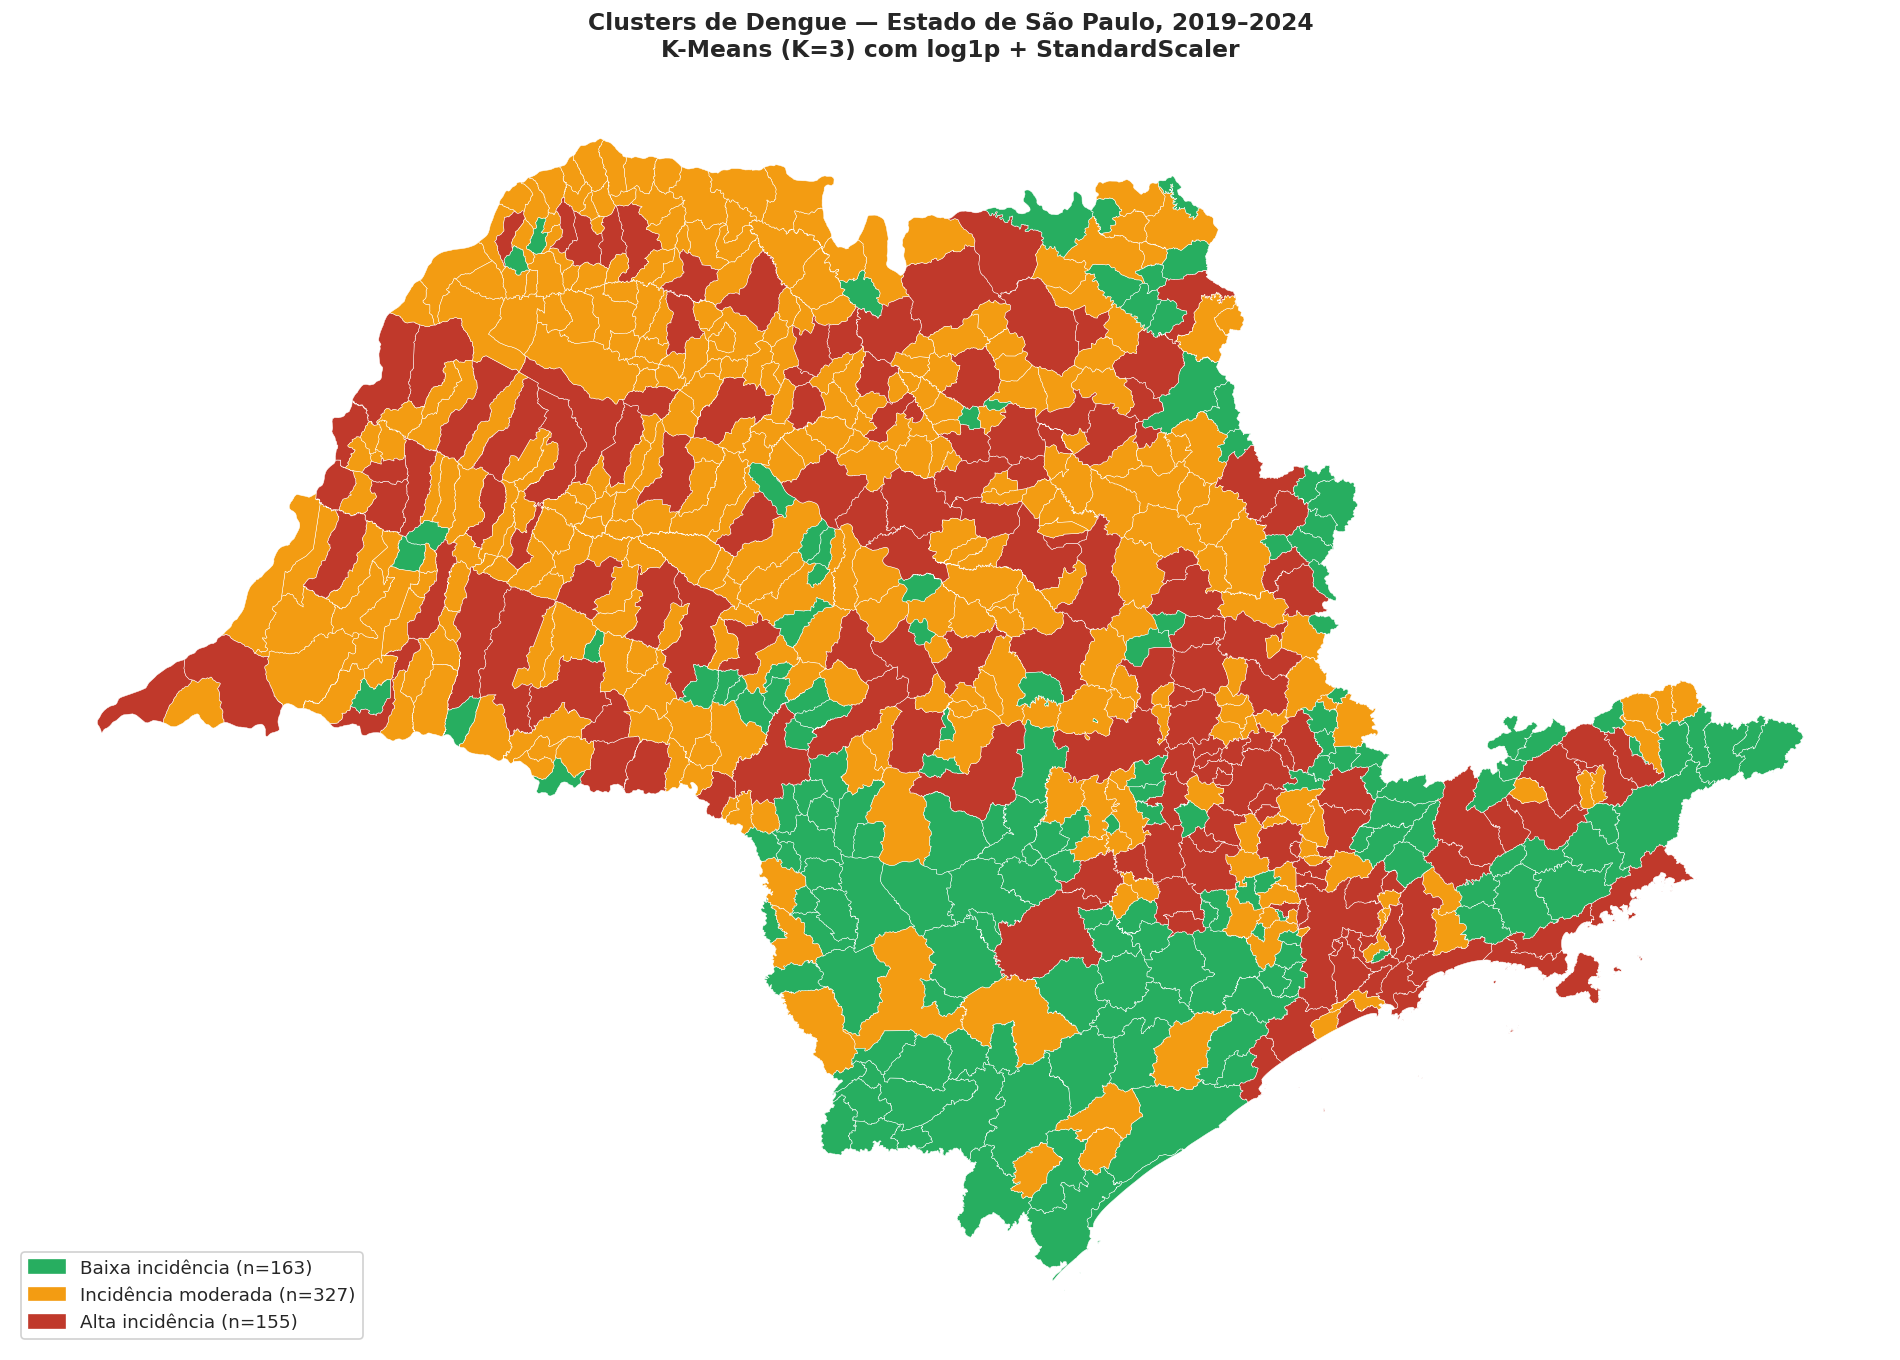

In [ ]:
# Biblioteca de mapas
!pip install -q geopandas

import geopandas as gpd
import matplotlib.patches as mpatches
import unicodedata
import requests, zipfile, io

# shapefile dos municípios de SP (IBGE)
url = "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/UFs/SP/SP_Municipios_2022.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("/tmp/sp_municipios")

gdf = gpd.read_file("/tmp/sp_municipios/SP_Municipios_2022.shp")

# Normaliza nomes
def normaliza(texto):
    texto = str(texto).upper().strip()
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    return texto

gdf['nome_norm'] = gdf['NM_MUN'].apply(normaliza)
df['nome_norm']  = df['Municipio'].apply(normaliza)

correcoes = {
    'SAO LUIS DO PARAITINGA': 'SAO LUIZ DO PARAITINGA'
}
df['nome_norm'] = df['nome_norm'].replace(correcoes)

# Merge
gdf_merged = gdf.merge(df[['nome_norm', 'Cluster']], on='nome_norm', how='left')

# Mapa
gdf_merged['cor'] = gdf_merged['Cluster'].map(cores_mapa).fillna('#CCCCCC')

fig, ax = plt.subplots(figsize=(16, 12))
gdf_merged.plot(color=gdf_merged['cor'], linewidth=0.3, edgecolor='white', ax=ax)

patches = [
    mpatches.Patch(color='#27AE60', label='Baixa incidência (n=163)'),
    mpatches.Patch(color='#F39C12', label='Incidência moderada (n=327)'),
    mpatches.Patch(color='#C0392B', label='Alta incidência (n=155)'),
]
ax.legend(handles=patches, loc='lower left', fontsize=11, framealpha=0.9)

ax.set_title('Clusters de Dengue — Estado de São Paulo, 2019–2024\nK-Means (K=3) com log1p + StandardScaler',
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('mapa_clusters_dengue_sp.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Lista municípios por cluster
for c in range(K_FINAL):
    municipios = df[df['Cluster'] == c]['Municipio'].tolist()
    print(f'\n* {rotulos[c]} - Cluster {c} ({len(municipios)} municípios):')
    print(', '.join(municipios))

# Exporta CSV
df['Cluster_nome'] = df['Cluster'].map(rotulos)
df['Total_2019_2024'] = df[ANOS].sum(axis=1)
df.sort_values(['Cluster', 'Total_2019_2024'], ascending=[True, False]).to_csv(
    'dengue_clusters_sp.csv', index=False, encoding='utf-8-sig')

print('\n=== RESUMO ===')
for c in range(K_FINAL):
    n = (df['Cluster'] == c).sum()
    print(f'  {rotulos[c]}: {n} municípios ({n/len(df)*100:.1f}%)')


* Alta incidência - Cluster 0 (155 municípios):
ADAMANTINA, AGUDOS, AMERICANA, AMERICO BRASILIENSE, AMPARO, ANDRADINA, ARACATUBA, ARARAQUARA, ARARAS, ARUJA, ASSIS, ATIBAIA, BADY BASSITT, BARRETOS, BARRINHA, BARUERI, BATATAIS, BAURU, BEBEDOURO, BERTIOGA, BIRIGUI, BOITUVA, BORBOREMA, BOTUCATU, BRAGANCA PAULISTA, BRODOWSKI, BROTAS, BURITAMA, CACAPAVA, CAIEIRAS, CAMPINAS, CANDIDO MOTA, CAPIVARI, CARAGUATATUBA, CASTILHO, CATANDUVA, CORDEIROPOLIS, CUBATAO, DIADEMA, DRACENA, ESTRELA D'OESTE, FERNANDOPOLIS, FRANCA, FRANCO DA ROCHA, GARCA, GUAIRA, GUAPIACU, GUARARAPES, GUARATINGUETA, GUARIBA, GUARUJA, GUARULHOS, HORTOLANDIA, IBITINGA, ILHABELA, INDAIATUBA, ITANHAEM, ITAPETININGA, ITAPOLIS, ITU, JABOTICABAL, JACAREI, JAGUARIUNA, JALES, JAU, JOSE BONIFACIO, JUNDIAI, JUNQUEIROPOLIS, LEME, LENCOIS PAULISTA, LIMEIRA, LINS, LORENA, MARILIA, MARTINOPOLIS, MATAO, MAUA, MIRANDOPOLIS, MOCOCA, MOGI DAS CRUZES, MOGI GUACU, MOGI MIRIM, MONTE ALTO, MORRO AGUDO, NHANDEARA, NOVA ODESSA, NOVO HORIZONTE, OLIMPI